# CH04_예측

---
## 4.1 선거 결과 예측하기
---

### 4.1.1: Loops in Python

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import os

os.chdir('/home/user/repo/studies/qss/data')

In [2]:
values = np.array([2,4,6])
n = len(values)
results = np.zeros(n)

for i in range(n):
    results[i] = values[i] * 2
    print(f"{values[i]} times 2 is equal to {results[i]}")

results

2 times 2 is equal to 4.0
4 times 2 is equal to 8.0
6 times 2 is equal to 12.0


array([ 4.,  8., 12.])

In [3]:
i = 0
x = values[i] * 2
print(f"{values[i]} times 2 is equal to {x}")

2 times 2 is equal to 4


In [4]:
values * 2

array([ 4,  8, 12])

### 4.1.2: General Conditional Statements in Python

In [5]:
operation = 'add'

if operation == 'add':
    print('I will perform addition 4 + 4')
    print(4 + 4)

if operation == 'multiply':
    print('I will perform multiplication 4 * 4')
    print(4 * 4)

I will perform addition 4 + 4
8


In [6]:
operation = 'multiply'

if operation == 'add':
    print('I will perform addition 4 + 4')
    print(4 + 4)
else:
    print('I will perform multiplication 4 * 4')
    print(4 * 4)

I will perform multiplication 4 * 4
16


In [7]:
operation = 'subtract'

if operation == 'add':
    print('I will perform addition 4 + 4')
    print(4 + 4)
elif operation == 'multiply':
    print('I will perform multiplication 4 * 4')
    print(4 * 4)
else:
    print(f"'{operation}' is invalid. Use either 'add' or 'multiply'")

'subtract' is invalid. Use either 'add' or 'multiply'


In [8]:
values = np.arange(1,6)
n = len(values)
results = np.zeros(n)

for i in range(n):
    x = values[i]
    r = x % 2
    if r == 0:
        print(f"{x} is even and I will perform addition {x} + {x}")
        results[i] = x + x
    else:
        print(f"{x} is add and I will perform multiplication {x} * {x}")
        results[i] = x * x

results


1 is add and I will perform multiplication 1 * 1
2 is even and I will perform addition 2 + 2
3 is add and I will perform multiplication 3 * 3
4 is even and I will perform addition 4 + 4
5 is add and I will perform multiplication 5 * 5


array([ 1.,  4.,  9.,  8., 25.])

### 4.1.3 여론조사 결과 예측

In [10]:
from datetime import datetime

In [13]:
pres08 = pd.read_csv('pres08.csv')
polls08 = pd.read_csv('polls08.csv')

In [14]:
polls08['margin'] = polls08.Obama - polls08.McCain
pres08['margin'] = pres08.Obama - pres08.McCain

In [17]:
pres08.head()

,state.name,state,Obama,McCain,EV,margin
0,Alabama,AL,39,60,9,-21
1,Alaska,AK,38,59,3,-21
2,Arizona,AZ,45,54,10,-9
3,Arkansas,AR,39,59,6,-20
4,California,CA,61,37,55,24


In [18]:
polls08.head()

,state,Pollster,Obama,McCain,middate,margin
0,AL,SurveyUSA-2,36,61,2008-10-27,-25
1,AL,Capital Survey-2,34,54,2008-10-15,-20
2,AL,SurveyUSA-2,35,62,2008-10-08,-27
3,AL,Capital Survey-2,35,55,2008-10-06,-20
4,AL,Rasmussen-1,39,60,2008-09-22,-21


In [20]:
x = datetime.strptime('2008-11-04', '%Y-%m-%d')
y = datetime.strptime('2008/9/1', '%Y/%m/%d')

x-y

datetime.timedelta(days=64)

In [22]:
(x-y).days

64

In [24]:
polls08['middate'] = pd.to_datetime(polls08['middate'])
polls08['days_to_election'] = (x - polls08['middate']).dt.days

In [61]:
st_names = polls08['state'].unique()
st_names

<StringArray>
['AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'HI', 'ID',
 'IL', 'IN', 'IA', 'KS', 'KY', 'LA', 'ME', 'MD', 'MA', 'MI', 'MN', 'MS', 'MO',
 'MT', 'NE', 'NV', 'NH', 'NJ', 'NM', 'NY', 'NC', 'ND', 'OH', 'OK', 'OR', 'PA',
 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VT', 'VA', 'WA', 'WV', 'WI', 'WY']
Length: 51, dtype: str

In [62]:
poll_pred = pd.Series(index=st_names)
poll_pred.head()

AL   NaN
AK   NaN
AZ   NaN
AR   NaN
CA   NaN
dtype: float64

In [66]:
for i in range(len(st_names)):
    state_data = polls08[polls08['state'] == st_names[i]]
    latest = (state_data[state_data['days_to_election'] == state_data['days_to_election'].min()])
    poll_pred.iloc[i] = latest['margin'].mean()

In [ ]:
poll_pred.head(10)

AL   -25.0
AK   -19.0
AZ    -2.5
AR    -7.0
CA    24.0
CO     7.0
CT    25.0
DC    69.0
DE    30.0
FL     2.0
dtype: float64

In [72]:
poll_pred_alt = pd.Series(index=st_names)

for state in st_names:
    state_data = polls08[polls08['state'] == state]
    latest = (state_data[state_data['days_to_election'] == 
                         state_data['days_to_election'].min()])
    poll_pred_alt[state] = latest['margin'].mean()

poll_pred.equals(poll_pred_alt)

True

In [78]:
errors = pres08.set_index('state')['margin'] - poll_pred
errors.head()

state
AL     4.0
AK    -2.0
AZ    -6.5
AR   -13.0
CA     0.0
dtype: float64

In [79]:
errors.mean()

np.float64(1.0620915032679739)

In [80]:
np.sqrt((errors**2).mean())

np.float64(5.908940458495747)

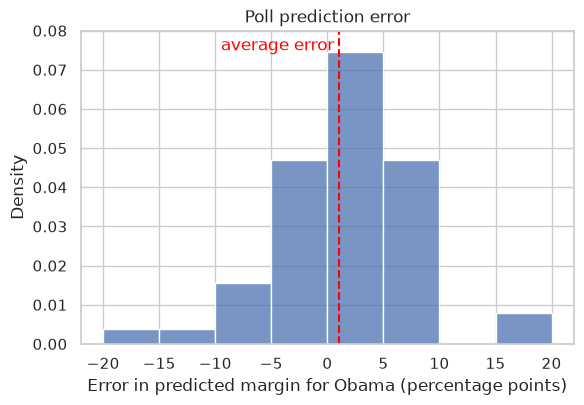

In [90]:
sns.set_theme(style="whitegrid")

sns.displot(
    x=errors, stat='density', binrange=(-20,20), binwidth=5,
    height=4, aspect=1.5,
).set(xlabel='Error in predicted margin for Obama (percentage points)',
      title='Poll prediction error',
      ylim=(0, 0.08)).despine(right=False, top=False)

plt.axvline(x=errors.mean(), color='red', linestyle='--')
plt.text(x=-9.5, y=0.075, s='average error', color='red');

In [95]:
pres08['poll_pred'] = poll_pred.reset_index(drop=True)

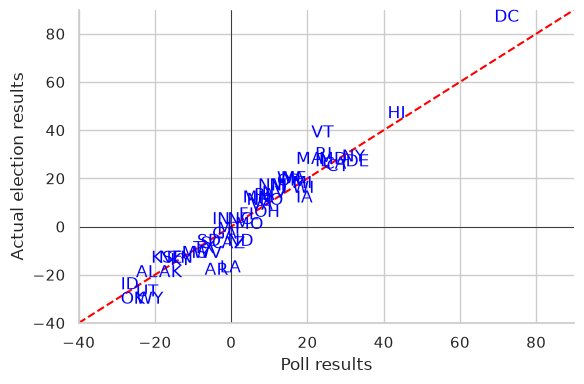

In [101]:
sns.relplot(
    data=pres08, x='poll_pred', y='margin', marker='',
    height=4, aspect=1.5,
).set(xlabel='Poll results', ylabel='Actual election results',
      ylim=(-40,90), xlim=(-40,90))

for i in range(len(pres08['state'])):
    plt.text(x=pres08['poll_pred'][i], y=pres08['margin'][i],
             s=pres08['state'][i], color='blue')

plt.gca().axline((0,0), slope=1, color='red', linestyle='--')

plt.axvline(x=0, color='black', linewidth=0.5)
plt.axhline(y=0, color='black', linewidth=0.5);

In [106]:
pres08['state'][np.sign(pres08['poll_pred']) != np.sign(pres08['margin'])]

14    IN
25    MO
33    NC
Name: state, dtype: str

In [107]:
pres08['margin'][np.sign(pres08['poll_pred']) != np.sign(pres08['margin'])]

14    1
25   -1
33    1
Name: margin, dtype: int64

In [112]:
pres08['EV'][pres08['margin'] > 0].sum()

np.int64(364)

In [113]:
pres08['EV'][pres08['poll_pred'] > 0].sum()

np.int64(349)

In [114]:
pollsUS08 = pd.read_csv('pollsUS08.csv', parse_dates=['middate'])
pollsUS08['days_to_election'] = (x - pollsUS08['middate']).dt.days

In [116]:
Obama_pred = np.zeros(90)
McCain_pred = np.zeros(90)

In [124]:
for i in range(len(Obama_pred)):
    week_data = (pollsUS08[(pollsUS08['days_to_election'] <= (90 - (i + 1) + 7))
                           & (pollsUS08['days_to_election'] > (90 - (i + 1)))])
    Obama_pred[i] = week_data['Obama'].mean()
    McCain_pred[i] = week_data['McCain'].mean()

pollsUS08_avg = pd.DataFrame({
    'Obama': Obama_pred,
    'McCain': McCain_pred,
    'days_to_election': np.arange(90, 0, -1)
})

pollsUS08_avg.head()

,Obama,McCain,days_to_election
0,44.538462,40.692308,90
1,45.000000,40.692308,89
2,45.230769,40.846154,88
3,45.750000,42.000000,87
4,45.888889,42.000000,86


In [125]:
pollsUS08_avg_long = pollsUS08_avg.melt(id_vars='days_to_election',
                                        var_name='Candidate',
                                        value_name='poll_avg')

pollsUS08_avg_long

,days_to_election,Candidate,poll_avg
0,90,Obama,44.538462
1,89,Obama,45.000000
2,88,Obama,45.230769
3,87,Obama,45.750000
4,86,Obama,45.888889
...,...,...,...
175,5,McCain,43.384615
176,4,McCain,43.708333
177,3,McCain,44.000000
178,2,McCain,44.185185


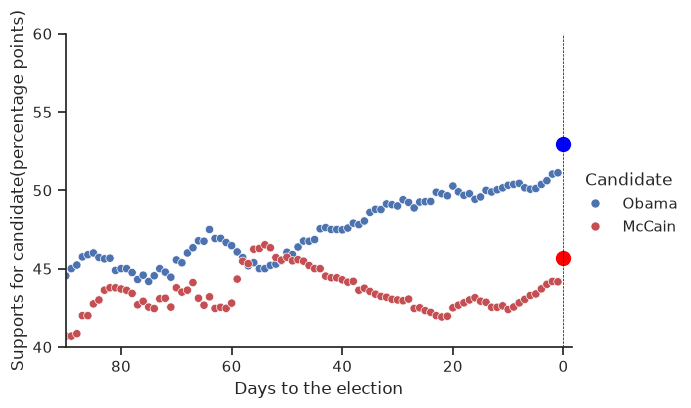

In [138]:
sns.set_theme(style='ticks')

sns.relplot(
    data=pollsUS08_avg_long, x='days_to_election', y='poll_avg',
    hue='Candidate', kind='scatter', # kind='line'
    palette=['b', 'r'], height=4, aspect=1.5
).set(
    ylim=(40, 60), yticks=range(40, 61, 5),
    xlim=(90, -1.5),
    xlabel='Days to the election',
    ylabel='Supports for candidate(percentage points)'
)

plt.axvline(x=0, color='black', linestyle='--', linewidth=.5)

plt.scatter(0, 52.93, color='blue', s=100)
plt.scatter(0, 45.65, color='red', s=100);

---
## 4.2 선형회귀
---

### 4.2.1 얼굴 생김새와 선거 결과

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import os

os.chdir('/home/user/repo/studies/qss/data')

In [2]:
face = pd.read_csv('face.csv')
face.head()

,year,state,winner,loser,w.party,l.party,d.comp,r.comp,d.votes,r.votes
0,2000,CA,Feinstein,Campbell,D,R,0.564568,0.435432,5790154,3779325
1,2000,DE,Carper,Roth,D,R,0.341912,0.658088,181387,142683
2,2000,FL,Nelson,McCollum,D,R,0.612368,0.387632,2987644,2703608
3,2000,GA,Miller,Mattingly,D,R,0.541533,0.458467,1390428,933698
4,2000,HI,Akaka,Carroll,D,R,0.680232,0.319768,251130,84657


In [3]:
face['d_share'] = face['d.votes'] / (face['d.votes'] + face['r.votes'])
face['r_share'] = face['r.votes'] / (face['d.votes'] + face['r.votes'])
face['diff_share'] = face['d_share'] - face['r_share']

In [4]:
face.head()

,year,state,winner,loser,w.party,l.party,d.comp,r.comp,d.votes,r.votes,d_share,r_share,diff_share
0,2000,CA,Feinstein,Campbell,D,R,0.564568,0.435432,5790154,3779325,0.605065,0.394935,0.210129
1,2000,DE,Carper,Roth,D,R,0.341912,0.658088,181387,142683,0.559715,0.440285,0.119431
2,2000,FL,Nelson,McCollum,D,R,0.612368,0.387632,2987644,2703608,0.524954,0.475046,0.049907
3,2000,GA,Miller,Mattingly,D,R,0.541533,0.458467,1390428,933698,0.598258,0.401742,0.196517
4,2000,HI,Akaka,Carroll,D,R,0.680232,0.319768,251130,84657,0.747885,0.252115,0.495770


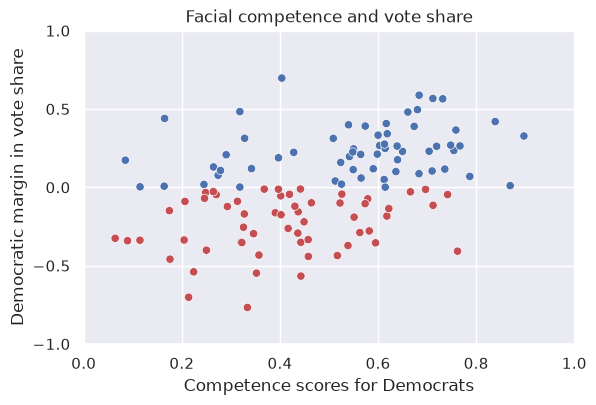

In [6]:
sns.relplot(
    data=face, x='d.comp', y='diff_share',
    hue='w.party', palette=['b', 'r'], legend=False, height=4, aspect=1.5,
).set(xlim=(0,1), ylim=(-1,1), yticks=np.arange(-1.0, 1.5, 0.5),
      title='Facial competence and vote share',
      xlabel='Competence scores for Democrats',
      ylabel='Democratic margin in vote share');

### 4.2.2 상관관계와 산점도

In [7]:
face['d.comp'].corr(face['diff_share'])

np.float64(0.43277434572761064)

### 4.2.3 최소제곱

In [8]:
import statsmodels.formula.api as smf

In [9]:
face.columns

Index(['year', 'state', 'winner', 'loser', 'w.party', 'l.party', 'd.comp',
       'r.comp', 'd.votes', 'r.votes', 'd_share', 'r_share', 'diff_share'],
      dtype='str')

In [10]:
face.columns = face.columns.str.replace('.', '_')
face.columns

Index(['year', 'state', 'winner', 'loser', 'w_party', 'l_party', 'd_comp',
       'r_comp', 'd_votes', 'r_votes', 'd_share', 'r_share', 'diff_share'],
      dtype='str')

In [12]:
fit = smf.ols('diff_share ~ d_comp', data=face).fit()

In [14]:
fit.model.formula

'diff_share ~ d_comp'

In [15]:
fit.params

Intercept   -0.312226
d_comp       0.660381
dtype: float64

In [18]:
fit.fittedvalues.head(10)

0    0.060604
1   -0.086433
2    0.092171
3    0.045392
4    0.136987
5   -0.100572
6   -0.045593
7    0.085994
8    0.043438
9    0.261788
dtype: float64

In [19]:
intercept, slope = fit.params
intercept, slope

(-0.31222587527907464, 0.6603814567765847)

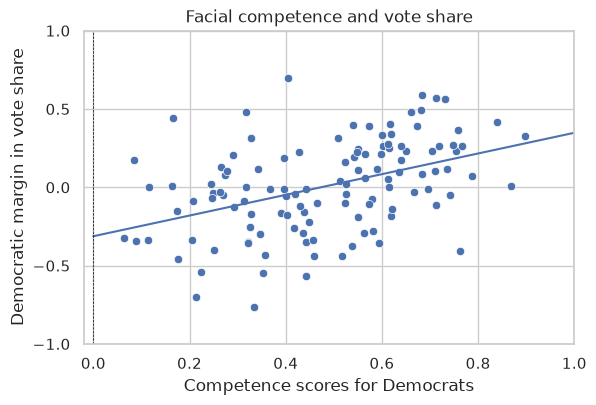

In [30]:
x_values = np.array([0,1])
y_values = intercept + slope * x_values

sns.set_theme(style='whitegrid')

sns.relplot(
    data=face, x='d_comp', y='diff_share', height=4, aspect=1.5
).set(ylim=(-1,1), yticks=np.arange(-1.0, 1.5, 0.5),
      xlim=(-0.02, 1),
      title='Facial competence and vote share',
      xlabel='Competence scores for Democrats',
      ylabel='Democratic margin in vote share').despine(right=False, top=False)

plt.plot(x_values, y_values)
plt.axvline(x=0, color='black', linewidth=.5, linestyle='--');

In [32]:
epsilon_hat = fit.resid
np.sqrt((epsilon_hat**2).mean())

np.float64(0.2642360764039512)

### 4.2.4 평균으로의 회귀